LeRobot not available. Will use simulated robot data instead.
=== Robot Trajectory Generation ===
Using simulated robot data...
Generating simulated robot trajectories...
Generated 50 simulated trajectories
Action dimension: 7 (7-DOF robot arm)
Dataset created with 50 trajectory segments
Action dimension: 7
Sequence length: 100
Model initialized with 0.20M parameters
Starting training...


Training Robot Model:   2%|▎                   | 12/800 [00:00<00:06, 117.49it/s]

Epoch 0, Loss: 0.136862, LR: 0.001000


Training Robot Model:  28%|█████▍             | 227/800 [00:01<00:03, 150.18it/s]

Epoch 200, Loss: 0.053040, LR: 0.000852


...

Training Robot Model:  78%|██████████████▉    | 628/800 [00:04<00:01, 148.55it/s]

Epoch 600, Loss: 0.056110, LR: 0.000145


Training Robot Model: 100%|███████████████████| 800/800 [00:05<00:00, 144.70it/s]


Generating new trajectories...


Visualizing results...


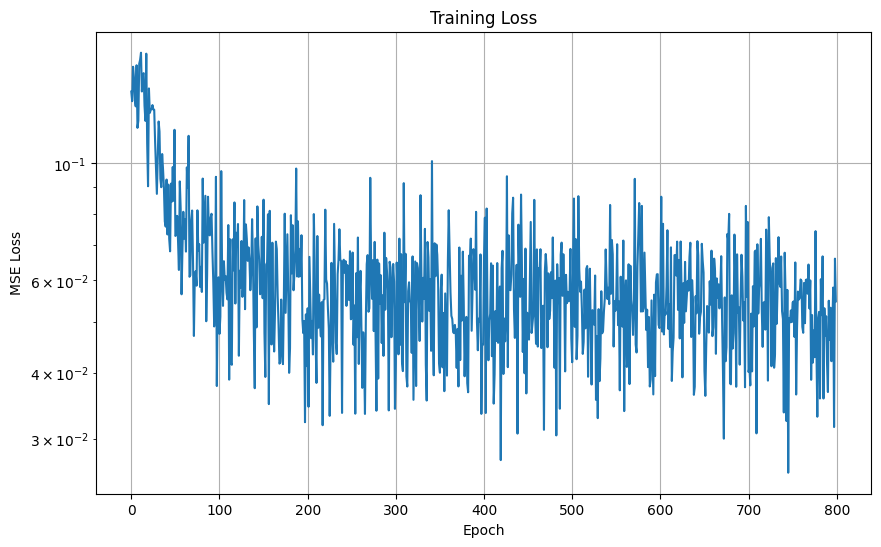

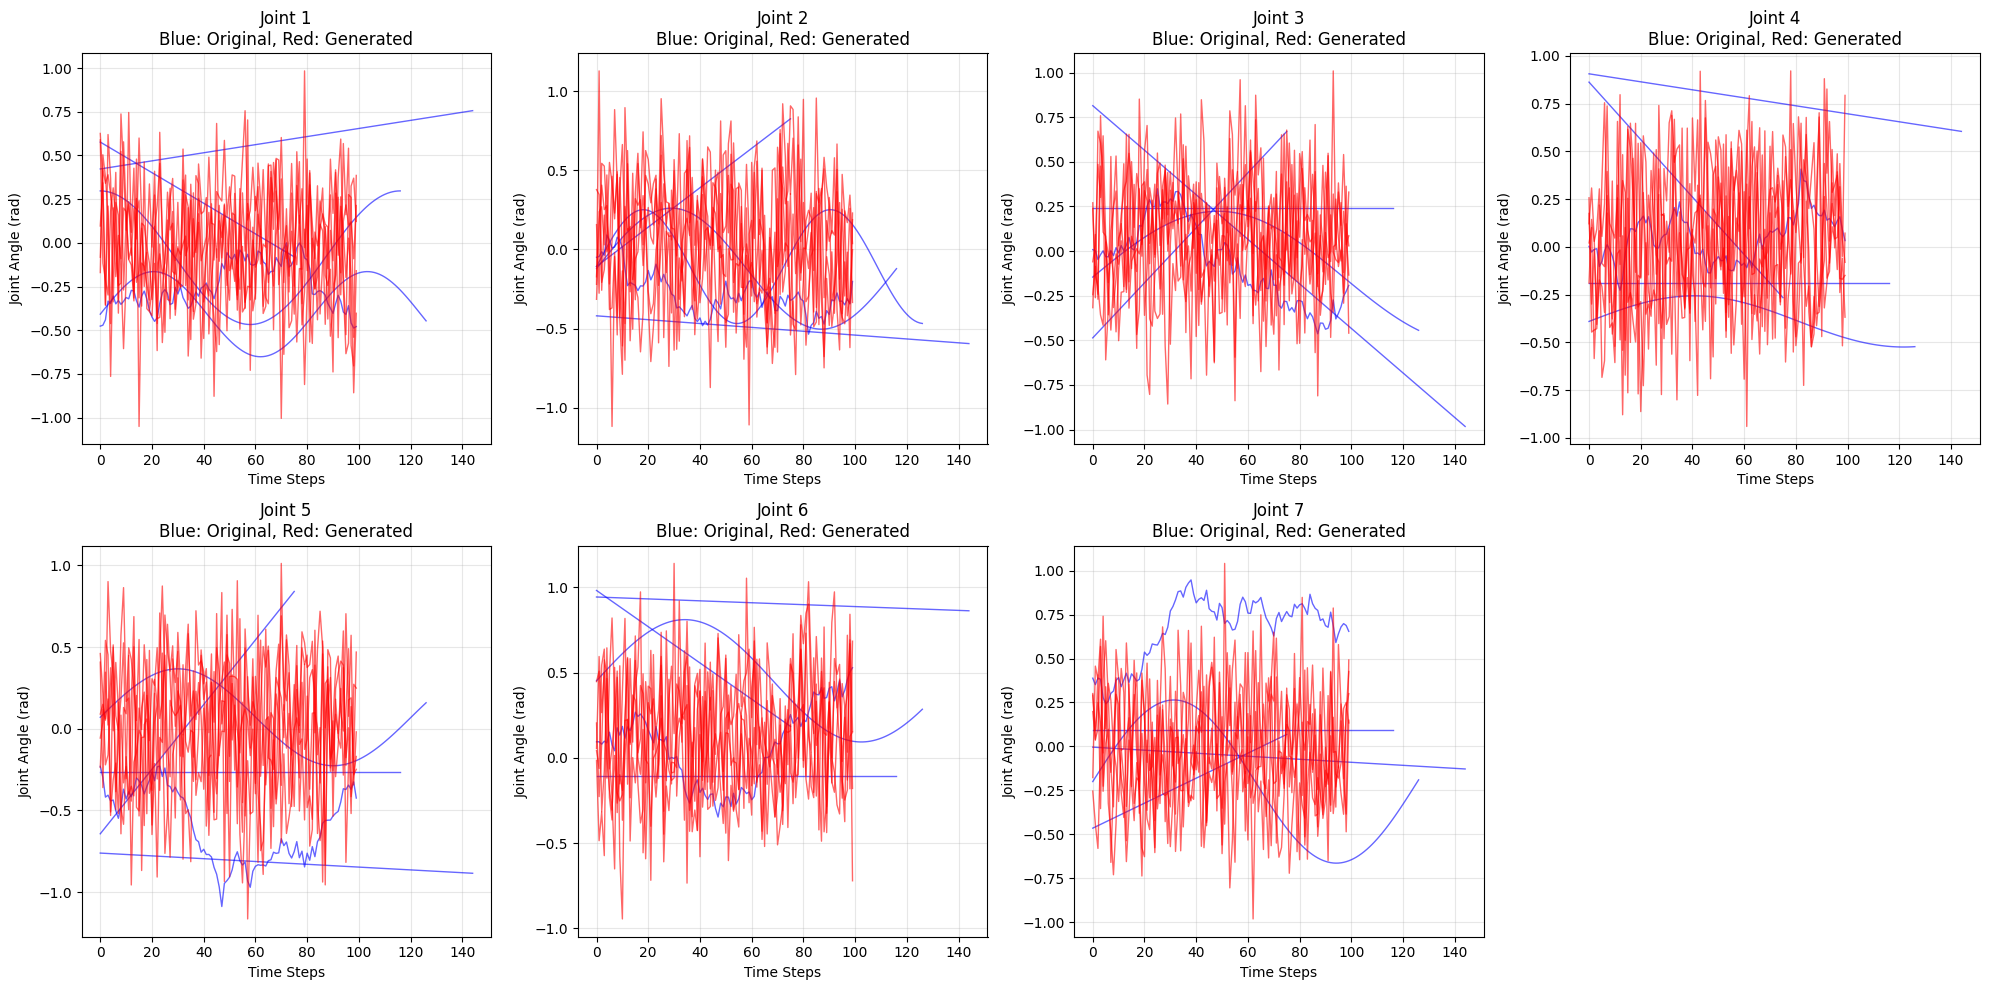

Training and generation completed!
Final loss: 0.054670


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# 注意：需要安装 lerobot: pip install lerobot
try:
    from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
    LEROBOT_AVAILABLE = True
except ImportError:
    print("LeRobot not available. Will use simulated robot data instead.")
    LEROBOT_AVAILABLE = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class RobotTrajectoryExtractor:
    """提取机械臂轨迹数据"""
    
    def __init__(self, repo_id="lerobot/aloha_mobile_cabinet", max_episodes=50):
        self.repo_id = repo_id
        self.max_episodes = max_episodes
        self.trajectories = []
        self.actions = []
        
    def extract_trajectories(self):
        """从LeRobot数据集提取轨迹"""
        if not LEROBOT_AVAILABLE:
            print("Using simulated robot data...")
            return self._generate_simulated_data()
        
        try:
            # 加载数据集
            print(f"Loading dataset: {self.repo_id}")
            dataset = LeRobotDataset(self.repo_id)
            
            print(f"Total episodes: {dataset.num_episodes}")
            print(f"Total frames: {dataset.num_frames}")
            
            # 限制处理的episode数量
            num_episodes = min(self.max_episodes, dataset.num_episodes)
            
            trajectories = []
            actions = []
            
            for episode_idx in tqdm(range(num_episodes), desc="Extracting trajectories"):
                # 获取episode的帧范围
                from_idx = dataset.episode_data_index["from"][episode_idx].item()
                to_idx = dataset.episode_data_index["to"][episode_idx].item()
                
                # 提取动作轨迹
                episode_actions = []
                episode_states = []
                
                for frame_idx in range(from_idx, min(to_idx, from_idx + 200)):  # 限制每个episode的长度
                    try:
                        frame_data = dataset[frame_idx]
                        
                        # 提取动作数据 (通常是关节位置/速度)
                        if 'action' in frame_data:
                            action = frame_data['action']
                            if isinstance(action, torch.Tensor):
                                episode_actions.append(action.cpu().numpy())
                        
                        # 提取状态数据 (机械臂位置)
                        if 'observation.state' in frame_data:
                            state = frame_data['observation.state']
                            if isinstance(state, torch.Tensor):
                                episode_states.append(state.cpu().numpy())
                                
                    except Exception as e:
                        print(f"Error processing frame {frame_idx}: {e}")
                        continue
                
                if len(episode_actions) > 10:  # 确保有足够的数据点
                    trajectories.append(np.array(episode_actions))
                    if len(episode_states) > 0:
                        actions.append(np.array(episode_states))
            
            self.trajectories = trajectories
            self.actions = actions
            
            print(f"Extracted {len(trajectories)} valid trajectories")
            if len(trajectories) > 0:
                print(f"Action dimension: {trajectories[0].shape[1]}")
                print(f"Average trajectory length: {np.mean([len(t) for t in trajectories]):.1f}")
            
            return trajectories, actions
            
        except Exception as e:
            print(f"Error loading dataset: {e}")
            print("Falling back to simulated data...")
            return self._generate_simulated_data()
    
    def _generate_simulated_data(self):
        """生成模拟的机械臂轨迹数据"""
        print("Generating simulated robot trajectories...")
        
        trajectories = []
        actions = []
        
        for i in range(50):  # 生成50个轨迹
            # 模拟7DOF机械臂的关节角度轨迹
            seq_len = np.random.randint(50, 150)
            t = np.linspace(0, 1, seq_len)
            
            # 生成不同类型的运动模式
            motion_type = i % 4
            
            if motion_type == 0:  # 平滑插值运动
                start_pos = np.random.uniform(-1, 1, 7)
                end_pos = np.random.uniform(-1, 1, 7)
                traj = np.outer(1-t, start_pos) + np.outer(t, end_pos)
                
            elif motion_type == 1:  # 正弦运动
                base_pos = np.random.uniform(-0.5, 0.5, 7)
                amplitude = np.random.uniform(0.1, 0.5, 7)
                frequency = np.random.uniform(0.5, 2.0, 7)
                traj = base_pos + amplitude * np.sin(2 * np.pi * frequency * t.reshape(-1, 1))
                
            elif motion_type == 2:  # 圆形运动 (前3个关节)
                center = np.random.uniform(-0.3, 0.3, 7)
                radius = np.random.uniform(0.2, 0.6)
                traj = center.copy()
                traj = np.tile(traj, (seq_len, 1))
                traj[:, 0] += radius * np.cos(2 * np.pi * t)
                traj[:, 1] += radius * np.sin(2 * np.pi * t)
                
            else:  # 随机游走
                start_pos = np.random.uniform(-0.5, 0.5, 7)
                noise = np.random.normal(0, 0.05, (seq_len, 7))
                traj = np.cumsum(noise, axis=0) + start_pos
                traj = np.clip(traj, -2, 2)
            
            trajectories.append(traj.astype(np.float32))
            actions.append(traj.astype(np.float32))  # 对于模拟数据，动作和状态相同
        
        self.trajectories = trajectories
        self.actions = actions
        
        print(f"Generated {len(trajectories)} simulated trajectories")
        print(f"Action dimension: 7 (7-DOF robot arm)")
        
        return trajectories, actions

class RobotTrajectoryDataset:
    """机械臂轨迹数据集"""
    
    def __init__(self, trajectories, seq_len=100, overlap=0.5):
        self.trajectories = trajectories
        self.seq_len = seq_len
        self.overlap = overlap
        self.segments = self._create_segments()
        
    def _create_segments(self):
        """将长轨迹切分成固定长度的片段"""
        segments = []
        
        for traj in self.trajectories:
            if len(traj) < self.seq_len:
                # 如果轨迹太短，进行插值
                try:
                    from scipy.interpolate import interp1d
                    t_old = np.linspace(0, 1, len(traj))
                    t_new = np.linspace(0, 1, self.seq_len)
                    f = interp1d(t_old, traj, axis=0, kind='linear')
                    traj_interp = f(t_new)
                    segments.append(traj_interp)
                except ImportError:
                    # 如果没有scipy，使用简单的线性插值
                    indices = np.linspace(0, len(traj)-1, self.seq_len)
                    traj_interp = np.array([traj[int(i)] for i in indices])
                    segments.append(traj_interp)
            else:
                # 切分长轨迹
                step = int(self.seq_len * (1 - self.overlap))
                for start_idx in range(0, len(traj) - self.seq_len + 1, step):
                    segment = traj[start_idx:start_idx + self.seq_len]
                    segments.append(segment)
        
        return [torch.tensor(seg, dtype=torch.float32) for seg in segments]
    
    def sample(self, num_samples):
        """采样轨迹片段"""
        indices = torch.randint(0, len(self.segments), (num_samples,))
        trajectories = torch.stack([self.segments[i] for i in indices]).to(device)
        labels = torch.zeros(num_samples, dtype=torch.long).to(device)  # 暂时不使用标签
        return trajectories, labels
    
    def __len__(self):
        return len(self.segments)

class RobotTrajectoryNet(nn.Module):
    """机械臂轨迹生成网络"""
    
    def __init__(self, action_dim=7, seq_len=100, hidden_dim=256, num_layers=4):
        super().__init__()
        self.action_dim = action_dim
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        
        # 时间编码
        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim//4),
            nn.ReLU(),
            nn.Linear(hidden_dim//4, hidden_dim//4)
        )
        
        # 轨迹编码
        self.traj_embed = nn.Sequential(
            nn.Linear(action_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim//2)
        )
        
        # 主网络
        self.network = nn.Sequential(
            nn.Linear(hidden_dim//4 + hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
        
    def forward(self, x, t, y=None):
        batch_size, seq_len, action_dim = x.shape
        
        # 时间编码
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        t_emb = self.time_embed(t)  # (bs, hidden_dim//4)
        t_emb = t_emb.unsqueeze(1).expand(-1, seq_len, -1)  # (bs, seq_len, hidden_dim//4)
        
        # 轨迹编码
        x_emb = self.traj_embed(x)  # (bs, seq_len, hidden_dim//2)
        
        # 拼接特征
        features = torch.cat([x_emb, t_emb], dim=-1)  # (bs, seq_len, hidden_dim)
        
        # 通过网络
        output = self.network(features)  # (bs, seq_len, action_dim)
        
        return output

def train_robot_model(model, dataset, num_epochs=1000, batch_size=16, lr=1e-3):
    """训练机械臂轨迹模型"""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)
    model.train()
    
    losses = []
    
    for epoch in tqdm(range(num_epochs), desc="Training Robot Model"):
        # 采样数据
        x1, _ = dataset.sample(batch_size)  # 真实轨迹
        
        # 生成噪声
        x0 = torch.randn_like(x1) * 0.1
        
        # 随机时间
        t = torch.rand(batch_size).to(device)
        
        # 线性插值
        alpha = (1 - t).view(-1, 1, 1)
        beta = t.view(-1, 1, 1)
        x_t = alpha * x0 + beta * x1
        
        # 真实速度场
        v_true = x1 - x0
        
        # 模型预测
        v_pred = model(x_t, t)
        
        # 损失
        loss = nn.MSELoss()(v_pred, v_true)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        losses.append(loss.item())
        
        if epoch % 200 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}, LR: {scheduler.get_last_lr()[0]:.6f}")
    
    model.eval()
    return losses

@torch.no_grad()
def generate_robot_trajectories(model, dataset, num_samples=10, num_steps=100):
    """生成机械臂轨迹"""
    # 初始噪声
    x = torch.randn(num_samples, dataset.seq_len, dataset.segments[0].shape[-1]).to(device) * 0.1
    
    # 生成过程
    dt = 1.0 / num_steps
    
    for i in tqdm(range(num_steps), desc="Generating", leave=False):
        t = torch.ones(num_samples).to(device) * (i * dt)
        v = model(x, t)
        x = x + v * dt
    
    return x

def visualize_robot_trajectories(original_trajs, generated_trajs, save_path=None):
    """可视化机械臂轨迹"""
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # 选择前7个关节进行可视化
    joint_names = [f'Joint {i+1}' for i in range(7)]
    
    for joint_idx in range(7):
        row = joint_idx // 4
        col = joint_idx % 4
        ax = axes[row, col]
        
        # 绘制原始轨迹
        for i, traj in enumerate(original_trajs[:5]):
            if joint_idx < traj.shape[1]:
                ax.plot(traj[:, joint_idx], alpha=0.6, color='blue', linewidth=1)
        
        # 绘制生成轨迹
        for i, traj in enumerate(generated_trajs[:5]):
            if joint_idx < traj.shape[1]:
                ax.plot(traj[:, joint_idx], alpha=0.6, color='red', linewidth=1)
        
        ax.set_title(f'{joint_names[joint_idx]}\nBlue: Original, Red: Generated')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Joint Angle (rad)')
    
    # 隐藏第8个子图
    axes[1, 3].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def main():
    """主函数"""
    print("=== Robot Trajectory Generation ===")
    
    # 1. 提取轨迹数据
    extractor = RobotTrajectoryExtractor(max_episodes=30)
    trajectories, actions = extractor.extract_trajectories()
    
    if len(trajectories) == 0:
        print("No trajectories extracted. Exiting.")
        return
    
    # 2. 创建数据集
    action_dim = trajectories[0].shape[1]
    seq_len = 100
    dataset = RobotTrajectoryDataset(trajectories, seq_len=seq_len)
    
    print(f"Dataset created with {len(dataset)} trajectory segments")
    print(f"Action dimension: {action_dim}")
    print(f"Sequence length: {seq_len}")
    
    # 3. 初始化模型
    model = RobotTrajectoryNet(
        action_dim=action_dim, 
        seq_len=seq_len, 
        hidden_dim=256
    ).to(device)
    
    print(f"Model initialized with {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")
    
    # 4. 训练模型
    print("Starting training...")
    losses = train_robot_model(model, dataset, num_epochs=800, batch_size=16, lr=1e-3)
    
    # 5. 生成新轨迹
    print("Generating new trajectories...")
    generated_trajs = generate_robot_trajectories(model, dataset, num_samples=10)
    generated_trajs_np = generated_trajs.cpu().numpy()
    
    # 6. 可视化结果
    print("Visualizing results...")
    
    # 绘制训练损失
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    plt.show()
    
    # 可视化轨迹对比
    original_trajs_sample = [traj for traj in trajectories[:10]]
    visualize_robot_trajectories(original_trajs_sample, generated_trajs_np)
    
    print("Training and generation completed!")
    print(f"Final loss: {losses[-1]:.6f}")
    
    return model, dataset, generated_trajs_np

if __name__ == "__main__":
    # 运行主程序
    model, dataset, generated_trajectories = main()

=== 使用 HuggingFace Datasets 的机械臂轨迹生成 ===

尝试数据集: lerobot/pusht
Loading HuggingFace dataset: lerobot/pusht
Error loading dataset lerobot/pusht: Feature type 'List' not found. Available feature types: ['Value', 'ClassLabel', 'Translation', 'TranslationVariableLanguages', 'LargeList', 'Sequence', 'Array2D', 'Array3D', 'Array4D', 'Array5D', 'Audio', 'Image', 'Video', 'Pdf']
✗ lerobot/pusht 加载失败

尝试数据集: lerobot/xarm_lift_medium
Loading HuggingFace dataset: lerobot/xarm_lift_medium
Extracting trajectories...


Processing samples: 500it [00:04, 113.96it/s]


Extracted 20 trajectories
Action dimension: 4
Average trajectory length: 25.0
✓ 成功加载 lerobot/xarm_lift_medium
数据集创建完成，包含 20 个轨迹片段
动作维度: 4
序列长度: 80
模型初始化完成，参数量: 0.20M
开始训练...


Training Robot Model:   6%|█▏                  | 35/600 [00:00<00:01, 349.24it/s]

Epoch 0, Loss: 0.481883


...

Training Robot Model:  78%|██████████████▉    | 470/600 [00:01<00:00, 361.88it/s]

Epoch 400, Loss: 0.129650


Training Robot Model: 100%|███████████████████| 600/600 [00:01<00:00, 344.05it/s]


生成新轨迹...


可视化结果...


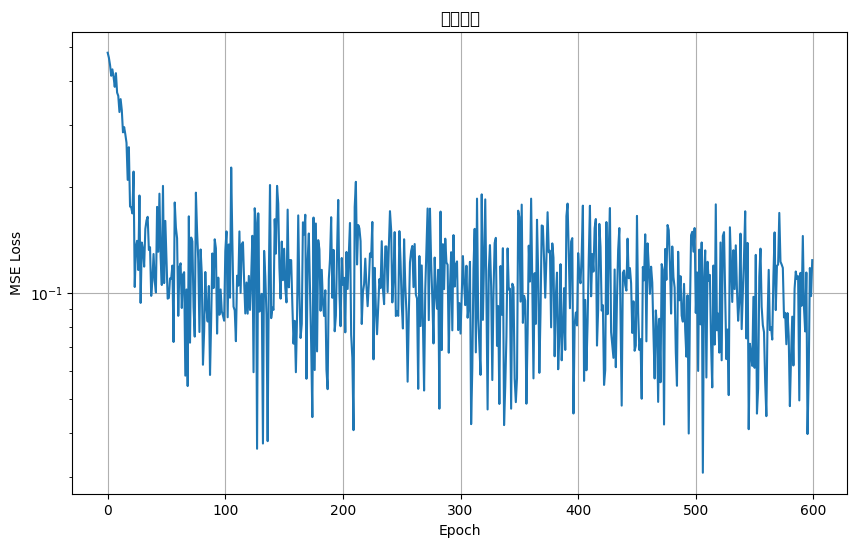

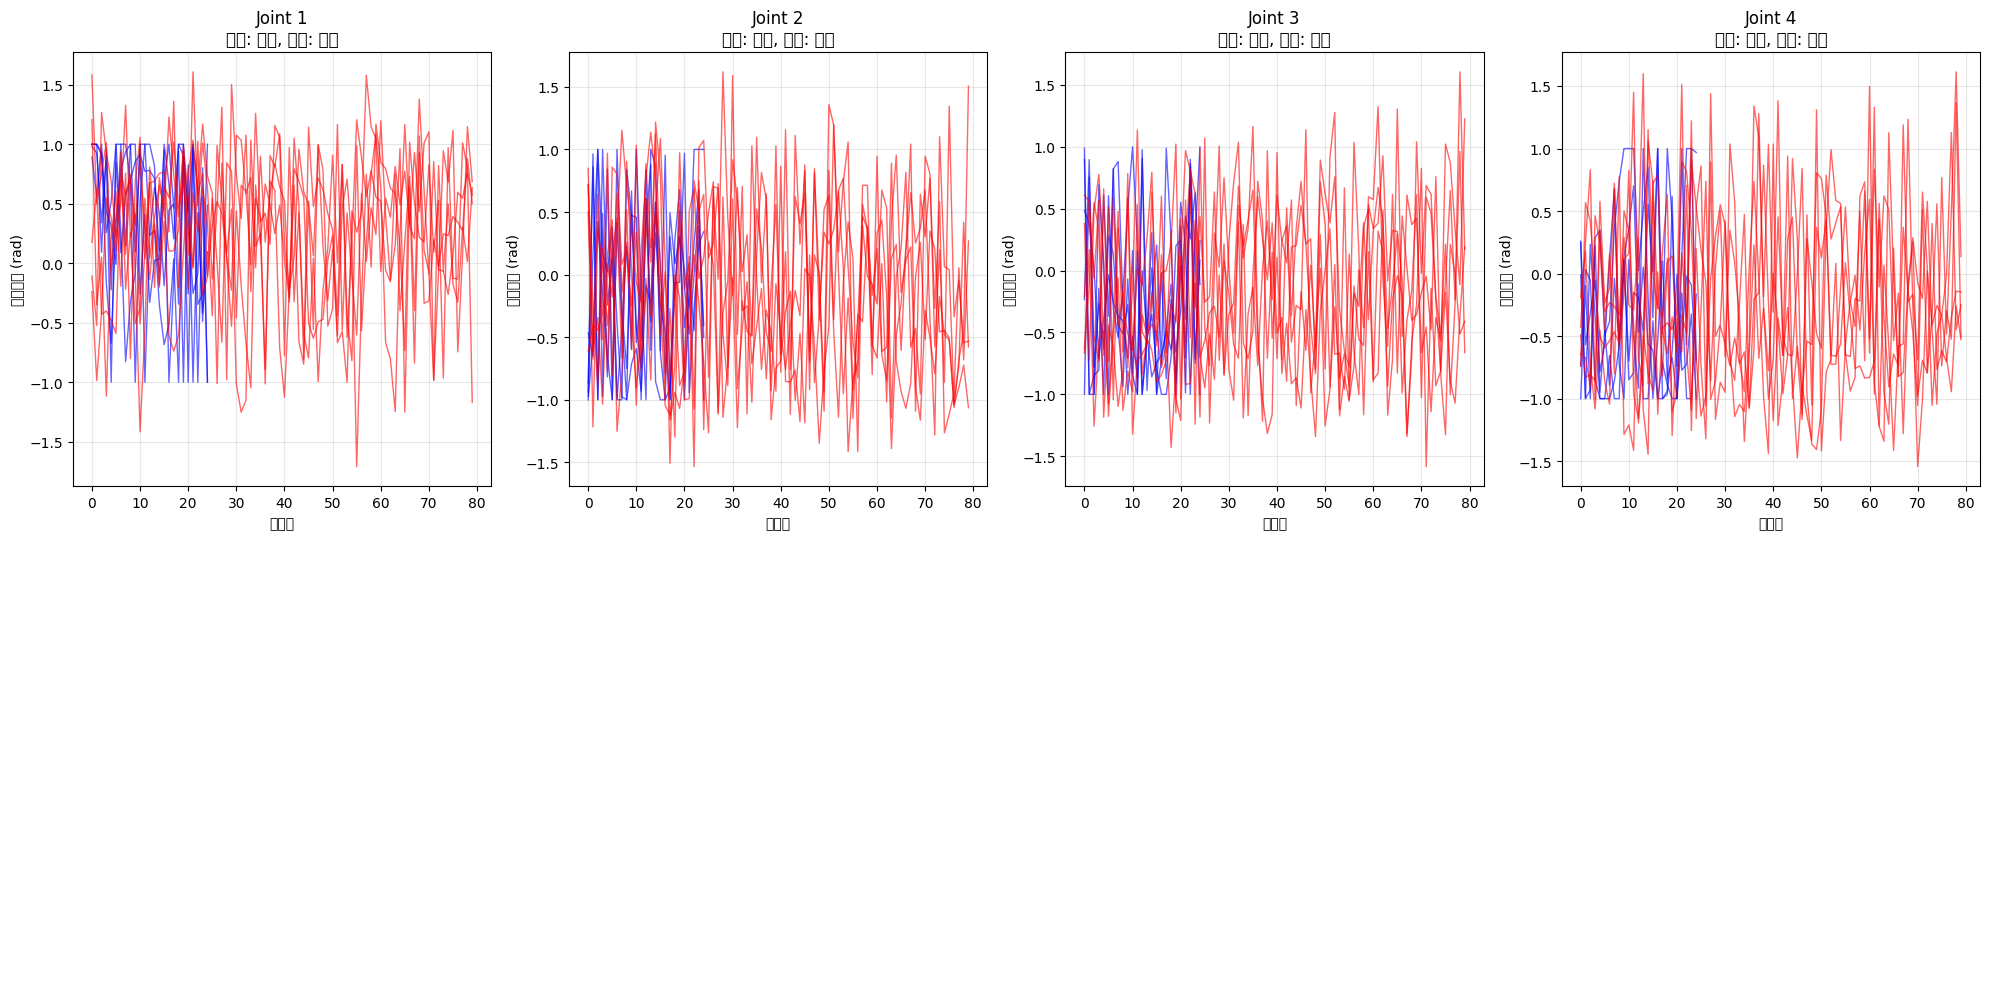

训练和生成完成！
最终损失: 0.123836


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# 使用 HuggingFace datasets 直接加载数据
from datasets import load_dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class HFRobotTrajectoryExtractor:
    """使用 HuggingFace datasets 直接提取机械臂轨迹"""
    
    def __init__(self, max_samples=1000):
        self.max_samples = max_samples
        self.trajectories = []
        
    def extract_from_hf_dataset(self, repo_id="lerobot/pusht"):
        """从 HuggingFace 数据集提取轨迹"""
        try:
            print(f"Loading HuggingFace dataset: {repo_id}")
            
            # 加载数据集
            dataset = load_dataset(repo_id, split="train", streaming=True)
            
            trajectories = []
            episode_actions = []
            current_episode_id = None
            
            print("Extracting trajectories...")
            for i, sample in enumerate(tqdm(dataset.take(self.max_samples), desc="Processing samples")):
                
                # 获取episode ID（如果有的话）
                episode_id = sample.get('episode_index', i // 50)  # 假设每50帧一个episode
                
                # 如果是新episode，保存上一个episode的数据
                if current_episode_id is not None and episode_id != current_episode_id:
                    if len(episode_actions) > 10:  # 确保有足够的数据点
                        trajectories.append(np.array(episode_actions))
                    episode_actions = []
                
                current_episode_id = episode_id
                
                # 提取动作数据
                if 'action' in sample:
                    action = sample['action']
                    if isinstance(action, (list, tuple)):
                        action = np.array(action, dtype=np.float32)
                    elif hasattr(action, 'numpy'):
                        action = action.numpy().astype(np.float32)
                    else:
                        action = np.array([action], dtype=np.float32)
                    
                    episode_actions.append(action)
            
            # 保存最后一个episode
            if len(episode_actions) > 10:
                trajectories.append(np.array(episode_actions))
            
            print(f"Extracted {len(trajectories)} trajectories")
            if len(trajectories) > 0:
                print(f"Action dimension: {trajectories[0].shape[1]}")
                print(f"Average trajectory length: {np.mean([len(t) for t in trajectories]):.1f}")
            
            self.trajectories = trajectories
            return trajectories
            
        except Exception as e:
            print(f"Error loading dataset {repo_id}: {e}")
            return []

    def try_multiple_datasets(self):
        """尝试多个数据集，找到能用的"""
        datasets_to_try = [
            "lerobot/pusht",
            "lerobot/xarm_lift_medium", 
            "lerobot/aloha_sim_insertion_human",
            "lerobot/aloha_mobile_cabinet"
        ]
        
        for dataset_name in datasets_to_try:
            print(f"\n尝试数据集: {dataset_name}")
            trajectories = self.extract_from_hf_dataset(dataset_name)
            
            if len(trajectories) > 0:
                print(f"✓ 成功加载 {dataset_name}")
                return trajectories
            else:
                print(f"✗ {dataset_name} 加载失败")
        
        print("所有真实数据集都失败，使用模拟数据")
        return self._generate_simulated_data()
    
    def _generate_simulated_data(self):
        """生成模拟的机械臂轨迹数据"""
        print("生成模拟机械臂轨迹...")
        
        trajectories = []
        
        for i in range(50):
            seq_len = np.random.randint(50, 150)
            t = np.linspace(0, 1, seq_len)
            
            # 生成不同类型的运动模式
            motion_type = i % 4
            
            if motion_type == 0:  # 平滑插值运动
                start_pos = np.random.uniform(-1, 1, 7)
                end_pos = np.random.uniform(-1, 1, 7)
                traj = np.outer(1-t, start_pos) + np.outer(t, end_pos)
                
            elif motion_type == 1:  # 正弦运动
                base_pos = np.random.uniform(-0.5, 0.5, 7)
                amplitude = np.random.uniform(0.1, 0.5, 7)
                frequency = np.random.uniform(0.5, 2.0, 7)
                traj = base_pos + amplitude * np.sin(2 * np.pi * frequency * t.reshape(-1, 1))
                
            elif motion_type == 2:  # 圆形运动
                center = np.random.uniform(-0.3, 0.3, 7)
                radius = np.random.uniform(0.2, 0.6)
                traj = center.copy()
                traj = np.tile(traj, (seq_len, 1))
                traj[:, 0] += radius * np.cos(2 * np.pi * t)
                traj[:, 1] += radius * np.sin(2 * np.pi * t)
                
            else:  # 随机游走
                start_pos = np.random.uniform(-0.5, 0.5, 7)
                noise = np.random.normal(0, 0.05, (seq_len, 7))
                traj = np.cumsum(noise, axis=0) + start_pos
                traj = np.clip(traj, -2, 2)
            
            trajectories.append(traj.astype(np.float32))
        
        self.trajectories = trajectories
        print(f"生成了 {len(trajectories)} 个模拟轨迹")
        return trajectories

class RobotTrajectoryDataset:
    """机械臂轨迹数据集"""
    
    def __init__(self, trajectories, seq_len=100, overlap=0.5):
        self.trajectories = trajectories
        self.seq_len = seq_len
        self.overlap = overlap
        self.segments = self._create_segments()
        
    def _create_segments(self):
        """将长轨迹切分成固定长度的片段"""
        segments = []
        
        for traj in self.trajectories:
            if len(traj) < self.seq_len:
                # 简单的线性插值
                indices = np.linspace(0, len(traj)-1, self.seq_len)
                traj_interp = np.array([traj[int(i)] for i in indices])
                segments.append(traj_interp)
            else:
                # 切分长轨迹
                step = max(1, int(self.seq_len * (1 - self.overlap)))
                for start_idx in range(0, len(traj) - self.seq_len + 1, step):
                    segment = traj[start_idx:start_idx + self.seq_len]
                    segments.append(segment)
        
        return [torch.tensor(seg, dtype=torch.float32) for seg in segments]
    
    def sample(self, num_samples):
        """采样轨迹片段"""
        indices = torch.randint(0, len(self.segments), (num_samples,))
        trajectories = torch.stack([self.segments[i] for i in indices]).to(device)
        labels = torch.zeros(num_samples, dtype=torch.long).to(device)
        return trajectories, labels
    
    def __len__(self):
        return len(self.segments)

class RobotTrajectoryNet(nn.Module):
    """机械臂轨迹生成网络"""
    
    def __init__(self, action_dim=7, seq_len=100, hidden_dim=256, num_layers=4):
        super().__init__()
        self.action_dim = action_dim
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        
        # 时间编码
        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim//4),
            nn.ReLU(),
            nn.Linear(hidden_dim//4, hidden_dim//4)
        )
        
        # 轨迹编码
        self.traj_embed = nn.Sequential(
            nn.Linear(action_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim//2)
        )
        
        # 主网络
        self.network = nn.Sequential(
            nn.Linear(hidden_dim//4 + hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
        
    def forward(self, x, t, y=None):
        batch_size, seq_len, action_dim = x.shape
        
        # 时间编码
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        t_emb = self.time_embed(t)
        t_emb = t_emb.unsqueeze(1).expand(-1, seq_len, -1)
        
        # 轨迹编码
        x_emb = self.traj_embed(x)
        
        # 拼接特征
        features = torch.cat([x_emb, t_emb], dim=-1)
        
        # 通过网络
        output = self.network(features)
        
        return output

def train_robot_model(model, dataset, num_epochs=800, batch_size=16, lr=1e-3):
    """训练机械臂轨迹模型"""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)
    model.train()
    
    losses = []
    
    for epoch in tqdm(range(num_epochs), desc="Training Robot Model"):
        # 采样数据
        x1, _ = dataset.sample(batch_size)  # 真实轨迹
        
        # 生成噪声
        x0 = torch.randn_like(x1) * 0.1
        
        # 随机时间
        t = torch.rand(batch_size).to(device)
        
        # 线性插值
        alpha = (1 - t).view(-1, 1, 1)
        beta = t.view(-1, 1, 1)
        x_t = alpha * x0 + beta * x1
        
        # 真实速度场
        v_true = x1 - x0
        
        # 模型预测
        v_pred = model(x_t, t)
        
        # 损失
        loss = nn.MSELoss()(v_pred, v_true)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        losses.append(loss.item())
        
        if epoch % 200 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    
    model.eval()
    return losses

@torch.no_grad()
def generate_robot_trajectories(model, dataset, num_samples=10, num_steps=100):
    """生成机械臂轨迹"""
    # 获取动作维度
    action_dim = dataset.segments[0].shape[-1]
    
    # 初始噪声
    x = torch.randn(num_samples, dataset.seq_len, action_dim).to(device) * 0.1
    
    # 生成过程
    dt = 1.0 / num_steps
    
    for i in tqdm(range(num_steps), desc="Generating", leave=False):
        t = torch.ones(num_samples).to(device) * (i * dt)
        v = model(x, t)
        x = x + v * dt
    
    return x

def visualize_robot_trajectories(original_trajs, generated_trajs, save_path=None):
    """可视化机械臂轨迹"""
    action_dim = min(original_trajs[0].shape[1], 7)  # 最多显示7个关节
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    joint_names = [f'Joint {i+1}' for i in range(action_dim)]
    
    for joint_idx in range(action_dim):
        row = joint_idx // 4
        col = joint_idx % 4
        ax = axes[row, col]
        
        # 绘制原始轨迹
        for i, traj in enumerate(original_trajs[:5]):
            if joint_idx < traj.shape[1]:
                ax.plot(traj[:, joint_idx], alpha=0.6, color='blue', linewidth=1)
        
        # 绘制生成轨迹
        for i, traj in enumerate(generated_trajs[:5]):
            if joint_idx < traj.shape[1]:
                ax.plot(traj[:, joint_idx], alpha=0.6, color='red', linewidth=1)
        
        ax.set_title(f'{joint_names[joint_idx]}\n蓝色: 原始, 红色: 生成')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('时间步')
        ax.set_ylabel('关节角度 (rad)')
    
    # 隐藏多余的子图
    for i in range(action_dim, 8):
        row = i // 4
        col = i % 4
        axes[row, col].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def main():
    """主函数"""
    print("=== 使用 HuggingFace Datasets 的机械臂轨迹生成 ===")
    
    # 1. 尝试提取真实轨迹数据
    extractor = HFRobotTrajectoryExtractor(max_samples=500)
    trajectories = extractor.try_multiple_datasets()
    
    if len(trajectories) == 0:
        print("无法加载任何数据集，程序退出")
        return
    
    # 2. 创建数据集
    action_dim = trajectories[0].shape[1]
    seq_len = 80  # 稍微短一点，训练更快
    dataset = RobotTrajectoryDataset(trajectories, seq_len=seq_len)
    
    print(f"数据集创建完成，包含 {len(dataset)} 个轨迹片段")
    print(f"动作维度: {action_dim}")
    print(f"序列长度: {seq_len}")
    
    # 3. 初始化模型
    model = RobotTrajectoryNet(
        action_dim=action_dim, 
        seq_len=seq_len, 
        hidden_dim=256
    ).to(device)
    
    print(f"模型初始化完成，参数量: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
    
    # 4. 训练模型
    print("开始训练...")
    losses = train_robot_model(model, dataset, num_epochs=600, batch_size=16, lr=1e-3)
    
    # 5. 生成新轨迹
    print("生成新轨迹...")
    generated_trajs = generate_robot_trajectories(model, dataset, num_samples=10)
    generated_trajs_np = generated_trajs.cpu().numpy()
    
    # 6. 可视化结果
    print("可视化结果...")
    
    # 训练损失
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title("训练损失")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    plt.show()
    
    # 轨迹对比
    original_trajs_sample = trajectories[:10]
    visualize_robot_trajectories(original_trajs_sample, generated_trajs_np)
    
    print("训练和生成完成！")
    print(f"最终损失: {losses[-1]:.6f}")
    
    return model, dataset, generated_trajs_np

if __name__ == "__main__":
    model, dataset, generated_trajectories = main()